# Assignment 10 - Class Work
## Topic: K-Means Clustering

### Question 1
Load the Iris dataset from sklearn.datasets. Display the first 10 rows and identify the features and target variable.

In [1]:
import pandas as pd
from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()

# Create a DataFrame
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target

# Display first 10 rows
print(df.head(10).to_string())

# Identify features and target
print('\nFeatures:', list(iris.feature_names))
print('Target variable: target (0=setosa, 1=versicolor, 2=virginica)')

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  species
0                5.1               3.5                1.4               0.2        0
1                4.9               3.0                1.4               0.2        0
2                4.7               3.2                1.3               0.2        0
3                4.6               3.1                1.5               0.2        0
4                5.0               3.6                1.4               0.2        0
5                5.4               3.9                1.7               0.4        0
6                4.6               3.4                1.4               0.3        0
7                5.0               3.4                1.5               0.2        0
8                4.4               2.9                1.4               0.2        0
9                4.9               3.1                1.5               0.1        0

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal lengt

### Question 2
Select two features (Petal Length and Petal Width) from the dataset for clustering.

In [2]:
print('----- Selected Features -----')

# Select two features: Petal Length and Petal Width
X = df[['petal length (cm)', 'petal width (cm)']].values

print('\nFeature 1: petal length (cm)')
print('Feature 2: petal width (cm)')
print('\nShape of selected feature matrix:', X.shape)
print()
print(df[['petal length (cm)', 'petal width (cm)']].head(10).to_string())

----- Selected Features -----

Feature 1: petal length (cm)
Feature 2: petal width (cm)

Shape of selected feature matrix: (150, 2)

   petal length (cm)  petal width (cm)
0                1.4               0.2
1                1.4               0.2
2                1.3               0.2
3                1.5               0.2
4                1.4               0.2
5                1.7               0.4
6                1.4               0.3
7                1.5               0.2
8                1.4               0.2
9                1.5               0.1


### Question 3
Apply K-Means clustering with K = 3 on the selected features. Print the cluster labels and cluster centroids.

In [3]:
from sklearn.cluster import KMeans

print('----- K-Means Clustering (K=3) -----')

# Apply K-Means with K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)
centroids = kmeans.cluster_centers_

print('\nK-Means Model Fitted Successfully.')
print('\nCluster Labels (first 20):', cluster_labels[:20].tolist())
print('\nCluster Centroids:')
for i, c in enumerate(centroids):
    print(f'  Cluster {i}: Petal Length = {c[0]:.4f}, Petal Width = {c[1]:.4f}')

----- K-Means Clustering (K=3) -----

K-Means Model Fitted Successfully.

Cluster Labels (first 20): [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Cluster Centroids:
  Cluster 0: Petal Length = 5.5958, Petal Width = 2.0375
  Cluster 1: Petal Length = 1.4620, Petal Width = 0.2460
  Cluster 2: Petal Length = 4.2692, Petal Width = 1.3423


### Question 4
Plot a scatter plot showing the K-Means clusters and mark the cluster centroids.

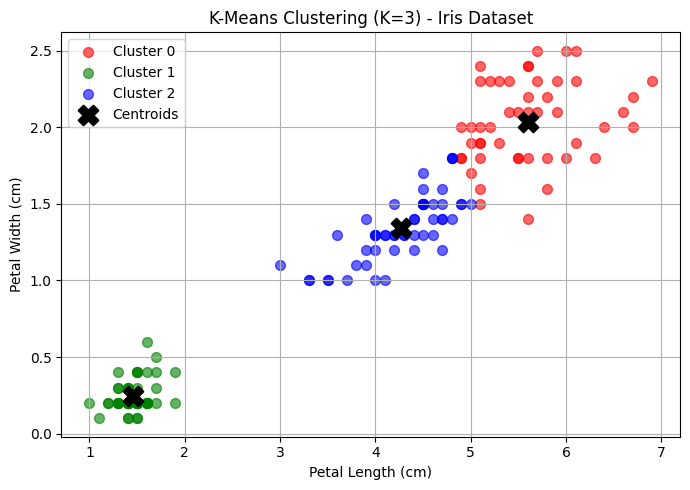

In [4]:
import matplotlib.pyplot as plt

colors = ['red', 'green', 'blue']

plt.figure(figsize=(7, 5))
for c in range(3):
    mask = cluster_labels == c
    plt.scatter(X[mask, 0], X[mask, 1], c=colors[c],
                label=f'Cluster {c}', alpha=0.6, s=50)

# Mark centroids
plt.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='X',
            s=200, linewidths=1.5, label='Centroids', zorder=5)

plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('K-Means Clustering (K=3) - Iris Dataset')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Question 5
Compare the cluster labels from K-Means with the true Iris species labels by plotting both side by side.

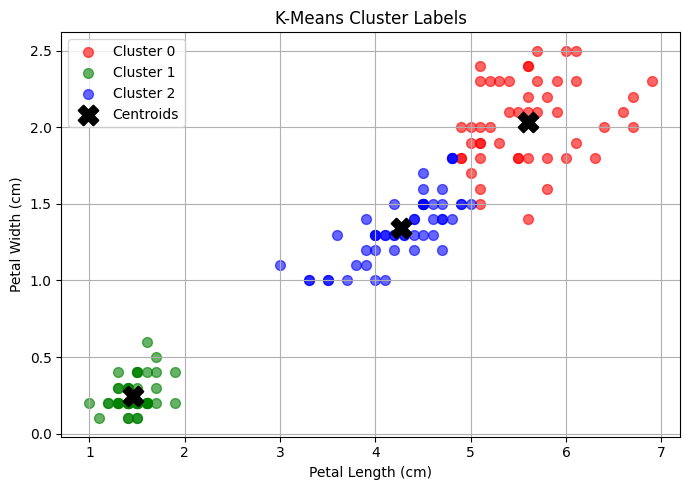

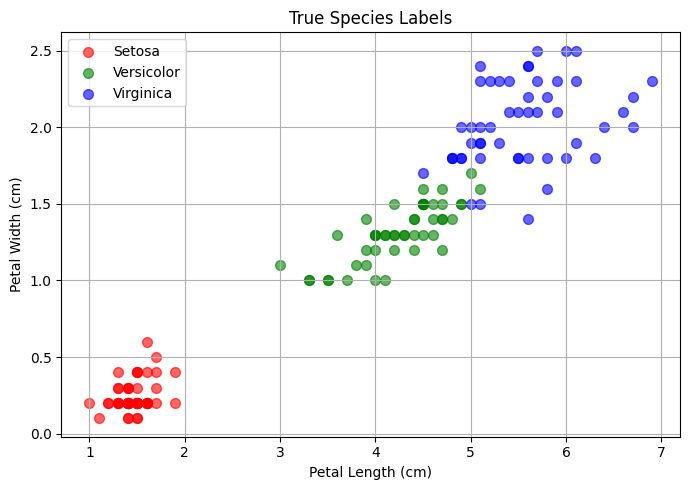

----- Comparison: K-Means vs True Labels -----

First 10 samples:
   K-Means Label  True Species Species Name
0              1             0       setosa
1              1             0       setosa
2              1             0       setosa
3              1             0       setosa
4              1             0       setosa
5              1             0       setosa
6              1             0       setosa
7              1             0       setosa
8              1             0       setosa
9              1             0       setosa

Note: K-Means cluster numbers may differ from true label numbers
      since clustering assigns arbitrary integer IDs to clusters.


In [5]:
true_labels  = iris.target
species_names = iris.target_names

# --- Plot 1: K-Means cluster labels ---
plt.figure(figsize=(7, 5))
for c in range(3):
    mask = cluster_labels == c
    plt.scatter(X[mask, 0], X[mask, 1], c=colors[c],
                label=f'Cluster {c}', alpha=0.6, s=50)
plt.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='X',
            s=200, linewidths=1.5, label='Centroids', zorder=5)
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('K-Means Cluster Labels')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Plot 2: True species labels ---
plt.figure(figsize=(7, 5))
for s in range(3):
    mask = true_labels == s
    plt.scatter(X[mask, 0], X[mask, 1], c=colors[s],
                label=species_names[s].capitalize(), alpha=0.6, s=50)
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('True Species Labels')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Tabular comparison ---
import pandas as pd
comp_df = pd.DataFrame({
    'K-Means Label': cluster_labels[:10],
    'True Species': true_labels[:10],
    'Species Name': [species_names[t] for t in true_labels[:10]]
})
print('----- Comparison: K-Means vs True Labels -----')
print('\nFirst 10 samples:')
print(comp_df.to_string(index=True))
print('\nNote: K-Means cluster numbers may differ from true label numbers')
print('      since clustering assigns arbitrary integer IDs to clusters.')

### Question 6
Calculate and print the Adjusted Rand Index (ARI) to evaluate the clustering performance.

In [6]:
from sklearn.metrics import adjusted_rand_score

print('----- Adjusted Rand Index (ARI) -----')

# Calculate ARI
ari = adjusted_rand_score(true_labels, cluster_labels)

print(f'\nARI Score: {ari:.4f}')
print('\nInterpretation:')
print('  ARI = 1.0  → Perfect clustering (matches true labels exactly)')
print('  ARI = 0.0  → Clustering is no better than random')
print('  ARI < 0.0  → Worse than random assignment')

if ari > 0.7:
    quality = 'good'
elif ari > 0.4:
    quality = 'moderate'
else:
    quality = 'poor'

print(f'\nARI = {ari:.4f} indicates {quality} agreement between K-Means clusters and true species labels.')

----- Adjusted Rand Index (ARI) -----

ARI Score: 0.8857

Interpretation:
  ARI = 1.0  → Perfect clustering (matches true labels exactly)
  ARI = 0.0  → Clustering is no better than random
  ARI < 0.0  → Worse than random assignment

ARI = 0.8857 indicates good agreement between K-Means clusters and true species labels.
